# Connect4
This notebook explores the application of Artificial Intelligence (AI) techniques to the classic strategy game Connect Four. We focus on two powerful and contrasting approaches to decision-making:

Monte Carlo Tree Search (MCTS): a simulation-based algorithm widely used in game AI, known for balancing exploration and exploitation to select optimal moves.

Decision Trees using ID3: a symbolic machine learning method that builds interpretable models based on information gain and entropy, trained on game state-action datasets.

### Objectives
Implement and analyze MCTS for playing Connect Four at different levels of simulation depth.

Generate datasets of game states and optimal moves using MCTS.

Train a Decision Tree using the ID3 algorithm on these datasets.

Compare performance and behavior between MCTS and ID3-based agents in gameplay.

Evaluate model accuracy, decision quality, and generalization ability

In [9]:
import random
import math 
import csv
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from numba import njit
from collections import Counter



## Game Logic
This section defines the core mechanics of the Connect Four game. It includes:

- Board creation and printing
- Move validation
- Piece placement
- Win condition checking



To ensure high performance — especially during Monte Carlo Tree Search simulations, which require thousands of board evaluations per second — we use Numba's @njit decorator to compile critical functions like:

- get_next_open_row_numba

These compiled versions significantly reduce execution time and allow our AI agents to make faster decisions.

In [3]:
ROWS = 6
COLS = 7



def create_board():
    return np.zeros((ROWS, COLS), dtype=np.uint8)

def print_board(board):
    for row in board:
        print(" ".join("X" if cell == 1 else "O" if cell == 2 else "-" for cell in row))

def board_to_string(board):
    return ''.join(str(int(cell)) for row in board for cell in row)

def state_key(board, player):
    # importante para a regra de repetição:
    # o mesmo tabuleiro com jogador diferente a jogar não é o mesmo estado
    return f"{player}|" + board_to_string(board)

def is_valid_drop(board, col):
    return 0 <= col < COLS and board[0, col] == 0

def is_valid_pop(board, col, player):
    return 0 <= col < COLS and board[ROWS - 1, col] == player

def get_next_open_row(board, col):
    for row in range(ROWS - 1, -1, -1):
        if board[row, col] == 0:
            return row
    return -1

def apply_drop(board, col, player):
    if not is_valid_drop(board, col):
        return None
    new_board = np.copy(board)
    row = get_next_open_row(new_board, col)
    new_board[row, col] = player
    return new_board

def apply_pop(board, col, player):
    if not is_valid_pop(board, col, player):
        return None
    new_board = np.copy(board)

    # a peça do fundo sai e tudo o que está acima desce uma casa
    for row in range(ROWS - 1, 0, -1):
        new_board[row, col] = new_board[row - 1, col]
    new_board[0, col] = 0

    return new_board

def apply_move(board, move, player):
    move_type, col = move

    if move_type == "drop":
        return apply_drop(board, col, player)
    elif move_type == "pop":
        return apply_pop(board, col, player)
    else:
        raise ValueError(f"Tipo de jogada desconhecido: {move_type}")

def get_valid_moves(board, player):
    moves = []

    for col in range(COLS):
        if is_valid_drop(board, col):
            moves.append(("drop", col))
        if is_valid_pop(board, col, player):
            moves.append(("pop", col))

    return moves

def check_winner(board, piece):
    # horizontal
    for r in range(ROWS):
        for c in range(COLS - 3):
            if all(board[r][c + i] == piece for i in range(4)):
                return True

    # vertical
    for r in range(ROWS - 3):
        for c in range(COLS):
            if all(board[r + i][c] == piece for i in range(4)):
                return True

    # diagonal principal
    for r in range(ROWS - 3):
        for c in range(COLS - 3):
            if all(board[r + i][c + i] == piece for i in range(4)):
                return True

    # diagonal secundária
    for r in range(3, ROWS):
        for c in range(COLS - 3):
            if all(board[r - i][c + i] == piece for i in range(4)):
                return True

    return False

def resolve_outcome(board, last_player, move, repetition_counts=None, allow_draw_on_full=False):
    """
    devolve:
      0  -> jogo continua
      1  -> ganha jogador 1
      2  -> ganha jogador 2
     -1  -> empate
    """
    p1 = check_winner(board, 1)
    p2 = check_winner(board, 2)

    # regra especial do enunciado:
    # se um pop criar 4-em-linha para ambos, ganha quem fez o pop
    if p1 and p2:
        if move[0] == "pop":
            return last_player
        return -1

    if p1:
        return 1
    if p2:
        return 2

    # regra da repetição
    if repetition_counts is not None:
        key = state_key(board, 3 - last_player)
        if repetition_counts[key] >= 3:
            return -1

    # tabuleiro cheio:
    # só é empate automático se o próximo jogador não tiver nenhum pop
    next_player = 3 - last_player
    if not np.any(board[0] == 0):
        valid_next_moves = get_valid_moves(board, next_player)
        has_pop = any(m[0] == "pop" for m in valid_next_moves)

        if not has_pop or allow_draw_on_full:
            return -1

    return 0

def encode_move(move):
    move_type, col = move
    return f"{move_type}_{col}"

def decode_move(label):
    move_type, col = label.split("_")
    return (move_type, int(col))

def board_to_state(board):
    state = {}
    index = 0
    for row in board:
        for cell in row:
            state[f"s{index}"] = int(cell)
            index += 1
    return state

def run_popout_sanity_tests():
    board = create_board()

    board = apply_move(board, ("drop", 0), 1)
    board = apply_move(board, ("drop", 0), 2)
    board = apply_move(board, ("drop", 1), 1)

    assert board[5, 0] == 1
    assert board[4, 0] == 2
    assert board[5, 1] == 1

    popped = apply_move(board, ("pop", 0), 1)
    assert popped is not None
    assert popped[5, 0] == 2
    assert popped[4, 0] == 0

    assert apply_move(board, ("pop", 1), 2) is None

    moves_p1 = get_valid_moves(board, 1)
    assert ("drop", 0) in moves_p1
    assert ("pop", 0) in moves_p1

    print("Sanity tests passed.")

## Brief Sanity Test

In [4]:
run_popout_sanity_tests()

Sanity tests passed.


## Random Algorithm
This is the simplest baseline AI agent for Connect Four.

Although it doesn't use any strategy or planning, this agent is useful for:

- Testing: Ensuring the game logic works as expected.

- Benchmarking: Comparing more sophisticated agents (like MCTS or ID3) against a non-deterministic baseline.

- Dataset generation: Providing diverse state distributions when used as an opponent.

In [5]:
def get_random_move(**kwargs):
    board = kwargs.get("board")
    player = kwargs.get("player")
    return random.choice(get_valid_moves(board, player))

## Monte Carlo Tree Search Algorithm
This section contains the full implementation of the MCTS algorithm. It explores the game tree using a balance of exploration and exploitation, guided by the Upper Confidence Bound formula.

This implementation is modular, allowing easy experimentation with:

- Different backpropagation strategies
- Exploration coefficients (c)
- Simulation depth
- Best-child criteria

In [11]:
class MCTSNode:
    __slots__ = ('board', 'player', 'parent', 'move', 'children', 'visits', 'wins', 'untried_moves')

    def __init__(self, board, player, parent=None, move=None):
        """
        player = jogador que fez a última jogada para chegar a este nó
        logo, quem joga agora é 3 - player
        """
        self.board = np.copy(board)
        self.player = player
        self.parent = parent
        self.move = move
        self.children = []
        self.visits = 0
        self.wins = 0
        self.untried_moves = get_valid_moves(self.board, 3 - self.player)

    def ucb1(self, total_simulations, c=0.9):
        if self.visits == 0:
            return float('inf')
        win_rate = self.wins / self.visits
        return win_rate + c * math.sqrt(math.log(max(total_simulations, 1)) / self.visits)


def node_outcome(node, repetition_counts=None):
    """
    devolve:
      0  -> continua
      1  -> ganha jogador 1
      2  -> ganha jogador 2
     -1  -> empate
    """
    if node.move is None:
        return 0
    return resolve_outcome(
        node.board,
        last_player=node.player,
        move=node.move,
        repetition_counts=repetition_counts
    )


def simulation(board, player_to_move, last_player=None, last_move=None):
    """
    rollout aleatório em Python puro
    devolve:
      1 ou 2 -> vencedor
      0      -> empate
    """
    sim_board = np.copy(board)
    repetition_counts = Counter()

    repetition_counts[state_key(sim_board, player_to_move)] += 1

    if last_player is not None and last_move is not None:
        outcome = resolve_outcome(
            sim_board,
            last_player=last_player,
            move=last_move,
            repetition_counts=repetition_counts
        )
        if outcome != 0:
            return 0 if outcome == -1 else outcome

    while True:
        valid_moves = get_valid_moves(sim_board, player_to_move)

        if not valid_moves:
            return 0

        move = random.choice(valid_moves)
        sim_board = apply_move(sim_board, move, player_to_move)

        next_player = 3 - player_to_move
        repetition_counts[state_key(sim_board, next_player)] += 1

        outcome = resolve_outcome(
            sim_board,
            last_player=player_to_move,
            move=move,
            repetition_counts=repetition_counts
        )

        if outcome != 0:
            return 0 if outcome == -1 else outcome

        player_to_move = next_player


def select_and_expand(node: MCTSNode, c=0.9):
    while True:
        outcome = node_outcome(node)
        if outcome != 0:
            return node

        if len(node.untried_moves) > 0:
            move = random.choice(node.untried_moves)
            node.untried_moves.remove(move)

            current_player = 3 - node.player
            new_board = apply_move(node.board, move, current_player)

            new_node = MCTSNode(
                board=new_board,
                player=current_player,
                parent=node,
                move=move
            )
            node.children.append(new_node)
            return new_node

        elif node.children:
            node = max(node.children, key=lambda child: child.ucb1(node.visits, c))
        else:
            return node


def backprograming_default(node: MCTSNode, result):
    while node is not None:
        node.visits += 1

        if result == node.player:
            node.wins += 1
        elif result == 0:
            node.wins += 0.5

        node = node.parent


def backprograming_greddy(node: MCTSNode, result):
    while node is not None:
        node.visits += 1

        if result == node.player:
            node.wins += 1
        elif result == 0:
            node.wins += 0.15

        node = node.parent


def bestchild_winPercentage(node: MCTSNode):
    if not node.children:
        return None

    visited_children = [child for child in node.children if child.visits > 0]
    if not visited_children:
        return None

    return max(visited_children, key=lambda child: child.wins / child.visits)


def bestchild_higherVisits(node: MCTSNode):
    if not node.children:
        return None

    visited_children = [child for child in node.children if child.visits > 0]
    if not visited_children:
        return None

    return max(visited_children, key=lambda child: child.visits)


def update_root(root, board, move, turn):
    """
    turn = jogador que acabou de fazer a jogada 'move'
    """
    matching_child = next((child for child in root.children if child.move == move), None)

    if matching_child:
        matching_child.parent = None
        return matching_child

    return MCTSNode(board=np.copy(board), player=turn)


def MCTS(**kwargs):
    root = kwargs.get("root")
    board = kwargs.get("board")
    player = kwargs.get("player")
    iterations = kwargs.get("iterations", 10000)
    bestchild = kwargs.get("bestchild", bestchild_winPercentage)
    backprograming = kwargs.get("backprograming", backprograming_default)
    c = kwargs.get("c", 0.9)

    if root is None:
        # se é a vez do player jogar, então o "último a jogar" foi o adversário
        root = MCTSNode(board, 3 - player)

    valid_moves = get_valid_moves(board, player)
    if not valid_moves:
        return None

    for _ in range(iterations):
        child = select_and_expand(root, c)

        outcome_now = node_outcome(child)
        if outcome_now != 0:
            result = 0 if outcome_now == -1 else outcome_now
        else:
            result = simulation(
                child.board,
                player_to_move=3 - child.player,
                last_player=child.player,
                last_move=child.move
            )

        backprograming(child, result)

    chosen = bestchild(root)

    if chosen is None:
        return random.choice(valid_moves)

    return chosen.move

## Save Monte Carlo moves data

This utility function is used to store game data generated by MCTS agents in a structured format for later use training a Decision Tree (ID3) on state 

### Format
- Each board state is stored as 42 individual features (s0 to s41), corresponding to the flattened 6×7 Connect Four grid.

- A final column move indicates the column selected by the MCTS agent.

In [6]:
def save_to_csv(data, filename="mcts_moves.csv"):
    fieldnames = [f"s{i}" for i in range(42)] + ["move"]

    write_header = not os.path.exists(filename)

    with open(filename, mode='a', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)

        if write_header:
            writer.writeheader()

        for entry in data:
            state_str = entry['state']
            move = entry['move']

            row = {f"s{i}": int(state_str[i]) for i in range(42)}
            row["move"] = move

            writer.writerow(row)

## Player vs Player/Ai

This function play_game() allows you to play Connect Four directly in the notebook using ipywidgets.

In [14]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def play_game(mode="pvc", ai=None):
    board = create_board()
    game_over = False
    turn = 1
    root = None

    repetition_counts = Counter()
    repetition_counts[state_key(board, turn)] += 1

    last_move = None
    last_symbol = None
    last_player = None

    if ai == MCTS or getattr(ai, "_is_mcts", False):
        root = MCTSNode(board, 2)  # antes da primeira jogada, consideramos que o "último" foi o jogador 2

    output = widgets.Output()
    display(output)

    def move_to_text(move):
        if move is None:
            return ""
        move_type, col = move
        return f"{move_type} na coluna {col}"

    def render():
        with output:
            clear_output(wait=True)
            print_board(board)

            if last_move is not None and last_symbol is not None and last_player is not None:
                if mode == "pvc" and last_player == 2:
                    jogador = "Computador"
                else:
                    jogador = "Jogador"
                print(f"Última jogada: {jogador} ({last_symbol}) fez {move_to_text(last_move)}")

            proximo_simbolo = 'X' if turn == 1 else 'O'
            proximo_jogador = "Jogador" if (mode == "pvp" or turn == 1) else "Computador"
            print(f"Próximo a jogar: {proximo_jogador} ({proximo_simbolo})")

            print("Jogadas válidas:", get_valid_moves(board, turn))

    def finish_game(outcome, winner_symbol=None, winner_name=None):
        nonlocal game_over
        with output:
            if outcome == -1:
                print("Empate!")
            else:
                print(f"{winner_name} ({winner_symbol}) venceu!")
        game_over = True

    def process_move(move, current_player, player_name):
        nonlocal board, root, turn, last_move, last_symbol, last_player, game_over

        if move not in get_valid_moves(board, current_player):
            with output:
                clear_output(wait=True)
                print_board(board)
                print(f"Jogada inválida: {move}")
            return False

        board = apply_move(board, move, current_player)

        next_player = 3 - current_player
        repetition_counts[state_key(board, next_player)] += 1

        last_move = move
        last_symbol = 'X' if current_player == 1 else 'O'
        last_player = current_player

        if root is not None:
            root = update_root(root, board, move, current_player)

        outcome = resolve_outcome(
            board,
            last_player=current_player,
            move=move,
            repetition_counts=repetition_counts
        )

        render()

        if outcome == -1:
            finish_game(-1)
            return False
        elif outcome in [1, 2]:
            winner_symbol = 'X' if outcome == 1 else 'O'
            finish_game(outcome, winner_symbol=winner_symbol, winner_name=player_name)
            return False

        turn = next_player
        return True

    def on_button_click(b):
        nonlocal turn, game_over

        if game_over:
            return

        desc = b.description
        move_type = "drop" if desc.startswith("D") else "pop"
        col = int(desc[1:])
        move = (move_type, col)

        player_name = "Jogador" if (mode == "pvp" or turn == 1) else "Computador"

        keep_playing = process_move(move, turn, player_name)
        if not keep_playing:
            return

        if mode == "pvc" and turn == 2 and ai:
            ai_move = ai(root=root, board=board, player=turn)
            if ai_move is None:
                finish_game(-1)
                return

            process_move(ai_move, 2, "Computador")

    drop_buttons = [widgets.Button(description=f"D{i}") for i in range(COLS)]
    pop_buttons = [widgets.Button(description=f"P{i}") for i in range(COLS)]

    for btn in drop_buttons + pop_buttons:
        btn.on_click(on_button_click)

    display(widgets.HTML("<b>Drop</b>"))
    display(widgets.HBox(drop_buttons))
    display(widgets.HTML("<b>Pop</b>"))
    display(widgets.HBox(pop_buttons))

    render()

In [8]:
play_game('pvc' , get_random_move)

Output()

In [10]:
play_game(mode= "pvp")

Output()

In [9]:
play_game(mode="pvc", ai= MCTS)

Output()

## Ai vs Ai 
The simulate_game() function allows you to run automated matches between two AI agents (e.g., MCTS vs ID3), track performance, and optionally log game states for training data.



In [ ]:
def simulate_game(ai1, ai2, silent=True, save=False):
    board = create_board()
    turn = 1

    root1 = MCTSNode(board, 2) if (ai1 == MCTS or getattr(ai1, "_is_mcts", False)) else None
    root2 = MCTSNode(board, 2) if (ai2 == MCTS or getattr(ai2, "_is_mcts", False)) else None

    repetition_counts = Counter()
    repetition_counts[state_key(board, turn)] += 1

    game_data = []

    total_time = {1: 0.0, 2: 0.0}
    move_count = {1: 0, 2: 0}

    while True:
        start_time = time.perf_counter()

        if turn == 1:
            move = ai1(board=board, root=root1, player=turn)
            if ai1 == MCTS or getattr(ai1, "_is_mcts", False):
                game_data.append({
                    'state': board_to_string(board),
                    'move': encode_move(move)
                })
        else:
            move = ai2(board=board, root=root2, player=turn)
            if ai2 == MCTS or getattr(ai2, "_is_mcts", False):
                game_data.append({
                    'state': board_to_string(board),
                    'move': encode_move(move)
                })

        end_time = time.perf_counter()
        total_time[turn] += (end_time - start_time)
        move_count[turn] += 1

        if move is None:
            if save:
                save_to_csv(game_data)
            return 0

        board = apply_move(board, move, turn)

        next_player = 3 - turn
        repetition_counts[state_key(board, next_player)] += 1

        if not silent:
            print_board(board)
            print(f"Player {turn} escolheu {move}")

        if root1 is not None:
            root1 = update_root(root1, board, move, turn)
        if root2 is not None:
            root2 = update_root(root2, board, move, turn)

        outcome = resolve_outcome(
            board,
            last_player=turn,
            move=move,
            repetition_counts=repetition_counts
        )

        if outcome != 0:
            avg1 = total_time[1] / move_count[1] if move_count[1] > 0 else 0
            avg2 = total_time[2] / move_count[2] if move_count[2] > 0 else 0

            if not silent:
                if outcome == -1:
                    print("It's a draw!")
                else:
                    print(f"Player {outcome} ({'X' if outcome == 1 else 'O'}) wins!")

                print(f"Average time per move — Player 1 (X): {avg1:.3f} seconds")
                print(f"Average time per move — Player 2 (O): {avg2:.3f} seconds")

            if save:
                save_to_csv(game_data)

            return 0 if outcome == -1 else outcome

        turn = next_player

In [11]:
simulate_game(MCTS,get_random_move,silent=True)

Player 1 (X) wins!
Average time per move — Player 1 (X): 6.020 seconds
Average time per move — Player 2 (O): 0.000 seconds


1

## Benchmark algorithms
This interactive menu lets you test and compare different Connect Four AI agents:

Choose between MCTS, ID3, or Random for each player.

(If MCTS is selected) Customize parameters like:
- Iterations
- UCB c value
- Best-child and backpropagation strategy
- Run up to 1000 games and view:
- Wins, draws, and average move time

Optionally:
- Show the game board
- Save MCTS move data to .csv for training

In [ ]:
def select_mcts_parameters(
    c=0.9,
    iterations=10000,
    bestchild_name= "bestchild_higherVisits",
    backprograming_name="backprograming_default"
):

    bestchild_options = {
        "bestchild_winPercentage":  bestchild_winPercentage,
        "bestchild_higherVisits": bestchild_higherVisits
    }

    backprograming_options = {
        "backprograming_default": backprograming_default,
        "backprograming_greddy": backprograming_greddy
    }

   
    if bestchild_name not in bestchild_options:
        raise ValueError(f"Função bestchild '{bestchild_name}' não encontrada.")
    if backprograming_name not in backprograming_options:
        raise ValueError(f"Função backprograming '{backprograming_name}' não encontrada.")

    return {
        "c": c,
        "iterations": iterations,
        "bestchild": bestchild_options[bestchild_name],
        "backprograming": backprograming_options[backprograming_name]
    }

def benchmark(strategy1, strategy2, games=20,silent=True, name1="AI1" , name2="AI2", save=False):
    ai1_wins = 0
    draws = 0

    for i in range(games):
        print(f"Simulating game {i+1} ...")
        winner = simulate_game( ai1=strategy1, ai2=strategy2,silent=silent,save=save)
        if winner == 1:
            ai1_wins += 1
        elif winner == 0:
            draws += 1
    print(f"{name1}: {ai1_wins}, Draws: {draws}, {name2}: {games - ai1_wins - draws}")
    
def benchmark_menu_jupyter():
    output = widgets.Output()
    
    
    ai_options = ["random", "mcts" , "id3"]
    ai1_dropdown = widgets.Dropdown(options=ai_options, description="AI 1:")
    ai2_dropdown = widgets.Dropdown(options=ai_options, description="AI 2:")

    
    games_slider = widgets.IntSlider(value=10, min=1, max=1000, step=1, description="Games:")

    
    show_board = widgets.Checkbox(value=False, description="Show board")

    save_moves= widgets.Checkbox(value=False, description='Save moves ')
    
    start_button = widgets.Button(description="Start Benchmark", button_style="success")

    
    mcts1_box = widgets.VBox()
    mcts2_box = widgets.VBox()

    def create_mcts_config(player_label="MCTS"):
        use_default = widgets.Checkbox(value=True, description=f"{player_label}: use default")

        
        
        bestchild = widgets.Dropdown(
            options=[ "bestchild_higherVisits", "bestchild_winPercentage"], 
            description="Bestchild:"
        )
        backprog = widgets.Dropdown(
            options=["backprograming_default", "backprograming_greddy"], 
            description="Backprog:"
        )
        c = widgets.FloatText(value=0.9, description="c:")
        iterations = widgets.IntText(value=10000, description="Iterations:")

        advanced_box = widgets.VBox([bestchild, backprog, c, iterations])
        advanced_box.layout.display = 'none'  

        def toggle_advanced_fields(change=None):
            advanced_box.layout.display = 'none' if use_default.value else 'block'

        use_default.observe(toggle_advanced_fields, names='value')

        box = widgets.VBox([use_default, advanced_box])

        def get_params():
            if use_default.value:
                return select_mcts_parameters()
            else:
                return select_mcts_parameters(
                    c=c.value,
                    iterations=iterations.value,
                    bestchild_name=bestchild.value,
                    backprograming_name=backprog.value
                )

        return box, get_params


    mcts1_cfg_box, get_mcts1_params = create_mcts_config("MCTS 1")
    mcts2_cfg_box, get_mcts2_params = create_mcts_config("MCTS 2")

    mcts1_box.children = [mcts1_cfg_box]
    mcts2_box.children = [mcts2_cfg_box]

    def toggle_mcts_boxes(*args):
        mcts1_box.layout.display = 'block' if ai1_dropdown.value == "mcts" else 'none'
        mcts2_box.layout.display = 'block' if ai2_dropdown.value == "mcts" else 'none'

    ai1_dropdown.observe(toggle_mcts_boxes, names='value')
    ai2_dropdown.observe(toggle_mcts_boxes, names='value')

    toggle_mcts_boxes()  

    def on_start_clicked(b):
        with output:
            clear_output()
            print("=== Benchmark Configuration ===")
            print(f"AI 1: {ai1_dropdown.value}")
            print(f"AI 2: {ai2_dropdown.value}")
            print(f"Games: {games_slider.value}")
            print(f"Show board: {'Yes' if show_board.value else 'No'}")
            
            
            mcts1_params = get_mcts1_params() if ai1_dropdown.value == "mcts" else {}
            mcts2_params = get_mcts2_params() if ai2_dropdown.value == "mcts" else {}

            def get_ai(name, params):
                if name == "random":
                    return get_random_move
                
                elif name == "id3":
                    return ID3

                elif name == "mcts":
                    ai_func = lambda **kwargs: MCTS(**{**kwargs, **params})
                    ai_func._is_mcts = True  
                    return ai_func
                else:
                    raise ValueError(f"Unkonwn AI : {name}")

            benchmark(
                strategy1=get_ai(ai1_dropdown.value, mcts1_params),
                strategy2=get_ai(ai2_dropdown.value, mcts2_params),
                games=games_slider.value,
                silent=not show_board.value,
                name1=ai1_dropdown.value.upper(),
                name2=ai2_dropdown.value.upper(),
                save=save_moves.value

            )

    start_button.on_click(on_start_clicked)

    
    display(widgets.VBox([
        widgets.HTML(value="<h3>Benchmark Menu</h3>"),
        ai1_dropdown,
        mcts1_box,
        ai2_dropdown,
        mcts2_box,
        games_slider,
        show_board,
        save_moves,
        start_button,
        output
    ]))


In [ ]:
benchmark_menu_jupyter()

### Some results

Best Child Strategy
Win %: bestchild_winPercentage vs bestchild_higherVisits
(200 games — Player 1 listed first)

- 30 rollouts:

    - WinPercentage: 123 wins

    - HigherVisits: 77 wins

- 500 rollouts:

    - WinPercentage: 107 wins

    - HigherVisits: 85 wins

- 10,000 rollouts:

    - WinPercentage: 39 wins

    - HigherVisits: 153 wins

Exploration Constant c (UCB1 Comparison)
(200 games — using bestchild_winPercentage)

- 1.41 vs 2.0 (10,000 rollouts):

    - 1.41: 140 wins

    - 2.0: 54 wins

- 1.41 vs 0.9 (100,000 rollouts):

    - 1.41: 79 wins

    - 0.9: 111 wins

- 0.9 vs 0.7 (100,000 rollouts):

    - 0.9: 100 wins

    - 0.7: 91 wins

Value of a Draw (in Backpropagation)
(10000 rollouts — comparing 0.5 vs 0.15 draw reward)

    - Draw value 0.5: 101 wins

    - Draw value 0.15: 90 wins

Lower c values and fair draw rewards generally improved long-term performance.
The choice of bestchild strategy matters more as rollouts increase.

## Analyzing data
The analyse_game_data() function loads the dataset generated from MCTS simulations and performs a frequency analysis of board states.

From it we can deduce that:
- Approximately 60% of the states are unique, indicating that most board configurations appear only once or a few times.
- The average number of moves per game is around 25, suggesting that many games end before the full board is filled.
- The dataset currently includes 80,000 unique states, which is a tiny fraction of the estimated 4,531,985,219 legal, playable states in Connect Four (based on the work of Victor Allis, 1988).

In [14]:
from collections import Counter

def analyse_game_data():
    df=pd.read_csv("mcts_moves.csv")

    board_cols = [f"s{i}" for i in range(42)]
    boards = df[board_cols]
    
    states = boards.apply(lambda row: tuple(row), axis=1)
    
    state_counts = Counter(states)
    
    print("Top 10 estados mais frequentes:")
    for state, count in state_counts.most_common(10):
        print(f"{state} → {count} vezes")
    
    print(f"\nTotal de estados únicos: {len(state_counts)}")
    print(f"Total de estados no ficheiro: {len(df)}")

In [15]:
analyse_game_data()

Top 10 estados mais frequentes:
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) → 5643 vezes
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0) → 3253 vezes
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0) → 2143 vezes
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0) → 780 vezes
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0) → 625 vezes
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 1, 1, 0, 0) → 604 vezes
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0) → 59

## Decision Tree Algorithm
This section implements a custom ID3 classification algorithm, built from scratch without using external libraries like scikit-learn. It constructs an interpretable decision tree from categorical or discretized data — ideal for Connect Four state → move classification.

Features
Entropy-based splitting using Information Gain

- Customizable parameters:

    - max_depth: limits tree depth to control complexity

    - min_samples_split: avoids splitting on very small groups

    - min_gain: minimum information gain to justify a split

- Stores:

    - The tree structure (TreeNode)

    - Attribute-value order used for splits (order)

Prediction Methods
- predict: returns the predicted class (move) for each input row
    (falls back to the most common move if no valid path is found)

- predict_probability: vectorized probability prediction for a dataset


In [13]:
class TreeNode(object):
    def __init__(self, indices = None, children = [], entropy = 0, depth = 0):
        self.indices = indices     
        self.entropy = entropy   
        self.depth = depth       
        self.split_attribute = None 
        self.children = children 
        self.order = None      
        self.label = None      

    def set_properties(self, split_attribute, order):
        self.split_attribute = split_attribute
        self.order = order

    def set_label(self, label):
        self.label = label


def entropy(freq):
   
    freq_0 = freq[np.array(freq).nonzero()[0]]
    prob_0 = freq_0/float(freq_0.sum())
    return -np.sum(prob_0*np.log2(prob_0))

class DecisionTreeID3(object):
    def __init__(self, max_depth=10, min_samples_split=2, min_gain=1e-4):
        self.root = None
        self.max_depth = max_depth 
        self.min_samples_split = min_samples_split 
        self.Ntrain = 0
        self.min_gain = min_gain
    
    def fit(self, data, target):
        self.Ntrain = data.count().iloc[0]
        self.data = data 
        self.attributes = list(data)
        self.target = target 
        self.labels = sorted(target.unique())  
        
        indices = range(self.Ntrain)
        self.root = TreeNode(indices=indices, entropy=self._entropy(indices), depth=0)
        queue = [self.root]
        while queue:
            node = queue.pop()
            if node.depth < self.max_depth and node.entropy > self.min_gain:  
                node.children = self._split(node)
                if not node.children: 
                    self._set_label(node)
                queue += node.children
            else:
                self._set_label(node)
                
    def _entropy(self, indices):
        if len(indices) == 0: return 0
        freq = np.array(self.target.iloc[indices].value_counts())
        return entropy(freq)

    def _set_label(self, node):
        node.set_label(self.target.iloc[node.indices].mode()[0]) 
    
    def _split(self, node):
        indices = node.indices 
        best_gain = 0
        best_splits = []
        best_attribute = None
        order = None
        sub_data = self.data.iloc[indices, :]
        for i, att in enumerate(self.attributes):
            values = self.data.iloc[indices, i].unique().tolist()
            if len(values) == 1: continue 
            splits = []
            for val in values: 
                sub_indices = sub_data.index[sub_data[att] == val].tolist()
                splits.append(sub_indices)
            if min(map(len, splits)) < self.min_samples_split: continue
            HxS = 0
            for split in splits:
                HxS += len(split) * self._entropy(split) / len(indices)
            gain = node.entropy - HxS 
            if gain < self.min_gain: continue
            if gain > best_gain:
                best_gain = gain 
                best_splits = splits
                best_attribute = att
                order = values
        node.set_properties(best_attribute, order)
        child_nodes = [TreeNode(indices=split,
                     entropy=self._entropy(split), depth=node.depth + 1) for split in best_splits]
        return child_nodes

    def predict(self, new_data):
        npoints = new_data.count().iloc[0]
        labels = [None] * npoints
        for n in range(npoints):
            x = new_data.iloc[n, :]
            node = self.root
            while node.children:
                value = x[node.split_attribute]
                if value in node.order:
                    idx = node.order.index(value)
                    node = node.children[idx]
                else:
                   
                    
                    break
            labels[n] = node.label if node.label is not None else self.target.iloc[node.indices].mode()[0]
        return labels

    def predict_proba(self, x):
        

        node = self.root
        while node.children:
            value = x[node.split_attribute]
            if value in node.order:
                idx = node.order.index(value)
                node = node.children[idx]
            else:
                return np.ones(len(self.labels)) / len(self.labels)

        probs = np.zeros(len(self.labels))
        if node.label in self.labels:
            i = self.labels.index(node.label)
            probs[i] = 1.0
        else:
            probs[:] = 1.0 / len(self.labels)
        return probs

    def predict_probability(self, df):

        return np.array([self.predict_proba(df.iloc[i]) for i in range(len(df))])



## Discretize

The discretize() function transforms continuous numerical attributes into categorical intervals using predefined thresholds. This step is essential for training decision trees like ID3, which operate on discrete values.

How it works:
- A copy of the DataFrame is created to avoid altering the original data.

- Each selected attribute (e.g., sepallength, petalwidth, etc.) is assigned a list of threshold values.

- Values are categorized as:

    - <= threshold

    - '>' last_threshold

In [17]:
def discretize(df):
    df_disc = df.copy()
    thresholds_dict = {
    "sepallength": [5.5, 6.7],
    "sepalwidth": [2.8, 3.6],
    "petallength": [2.9, 4.9],
    "petalwidth": [0.9, 1.7],
    }
    def discretize_value(value, thresholds):
        for i, threshold in enumerate(thresholds):
            if value <= threshold:
                return f"<= {threshold}"
        return f"> {thresholds[-1]}"

    for col, thresholds in thresholds_dict.items():
        df_disc[col] = df[col].apply(lambda x: discretize_value(x, thresholds))
    
    return df_disc





## Train-Test Split
The train_test_split() function splits a DataFrame into training and testing sets

Function Behavior
- Shuffles the data with a fixed random seed (random_state=42) to ensure reproducibility.

- Splits the dataset based on the split ratio (default: 70% training / 30% testing).

- Separates features (X) from the target column (y).

Returns
- X_train: training features

- X_test: testing features

- y_train: training labels

- y_test: testing labels

In [18]:
def train_test_split(data,split=0.7,target="class"):
    data = data.sample(frac=1,random_state=42).reset_index(drop=True)


    split_size=int(len(data) *split)

    
    train_data = data.iloc[:split_size]
    test_data = data.iloc[split_size:]

    X_train = train_data.drop(columns=[target])
    y_train = train_data[target]

    X_test = test_data.drop(columns=[target])
    y_test = test_data[target]

    return X_train,X_test,y_train,y_test

## Performance metrics
This section provides tools to evaluate the performance of decision trees (or other classifiers) using cross-validation and standard classification metrics.

### k_fold_cross_validation()
Performs K-Fold Cross-Validation:

- Shuffles and splits the dataset into k folds

- Trains and evaluates an ID3 decision tree on each fold

- Discretizes features before training

- Returns accuracy per fold, and prints:

    - Mean accuracy

    - Standard deviation

Additional Metrics
- accuracy(y_pred, y_true): Computes overall accuracy (proportion of correct predictions)

- confusion_matrix(y_true, y_pred):

    - Visualizes a confusion matrix with seaborn.heatmap

    - Supports custom label ordering

- precision_recall_f1(y_true, y_pred):

    - Computes precision, recall, and F1-score per class

In [19]:
def k_fold_cross_validation(df, target_col, k=5, max_depth=3, min_samples_split=3):

    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    fold_size = len(df) // k
    metrics = []

    for i in range(k):
        start, end = i * fold_size, (i + 1) * fold_size
        
        test_df = df.iloc[start:end]
        train_df = pd.concat([df.iloc[:start], df.iloc[end:]])

        X_train = discretize(train_df.drop(columns=[target_col])).reset_index(drop=True)
        y_train = train_df[target_col].reset_index(drop=True)


        X_test = discretize(test_df.drop(columns=[target_col]) ).reset_index(drop=True)
        y_test = test_df[target_col].reset_index(drop=True)


        tree = DecisionTreeID3(max_depth=max_depth, min_samples_split=min_samples_split)
        tree.fit(X_train, y_train)
        y_pred = tree.predict(X_test)

        acc = sum(yt == yp for yt, yp in zip(y_test, y_pred)) / len(y_test)
        metrics.append(acc)

    print(f"K-Fold Accuracy por fold: {metrics}")
    print(f"Média: {np.mean(metrics):.4f} | Desvio padrão: {np.std(metrics):.4f}")
    return metrics

def accuracy(predicton,true):
    return sum(yt==yp for yp,yt in zip(predicton,true)) / len(true)

def confusion_matrix(y_true, y_pred, labels=None, title="Confusion Matrix"):
    if labels is None:
        labels = sorted(set(y_true) | set(y_pred))
    
    matrix = pd.DataFrame(
        np.zeros((len(labels), len(labels)), dtype=int),
        index=labels, columns=labels
    )

    for t, p in zip(y_true, y_pred):
        matrix.loc[t, p] += 1

    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=True, 
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def precision_recall_f1(y_true, y_pred):
    from collections import Counter
    labels = sorted(set(y_true) | set(y_pred))
    tp = Counter()
    fp = Counter()
    fn = Counter()
    for yt, yp in zip(y_true, y_pred):
        if yt == yp:
            tp[yt] += 1
        else:
            fp[yp] += 1
            fn[yt] += 1
    metrics = {}
    for label in labels:
        p = tp[label] / (tp[label] + fp[label]) if (tp[label] + fp[label]) else 0
        r = tp[label] / (tp[label] + fn[label]) if (tp[label] + fn[label]) else 0
        f1 = 2 * p * r / (p + r) if (p + r) else 0
        metrics[label] = {"precision": p, "recall": r, "f1-score": f1}
    return metrics

## ROC Curve and AUC
This section provides a full implementation of ROC curve plotting and AUC (Area Under Curve) computation for multiclass classifiers.

Functions Included
- one_hot_encode(y): Converts class labels into one-hot encoded vectors

- compute_roc_curve(y_true_bin, y_score): Computes the TPR and FPR at various thresholds for one class

- trapezoidal_auc(x, y): Calculates the AUC using the trapezoidal rule

- plot_roc(y_true, y_proba, class_labels):

    - Supports multiclass ROC

    - Accepts predicted probabilities (y_proba) and true labels

    - Plots one curve per class

    - Calculates and displays AUC for each class

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def one_hot_encode(y, num_classes=None):
    if num_classes is None:
        num_classes = np.max(y) + 1
    return np.eye(num_classes)[y]

def compute_roc_curve(y_true_bin, y_score):
    thresholds = np.linspace(0, 1, num=100)
    tpr_list, fpr_list = [], []
    for thresh in thresholds:
        y_pred = (y_score >= thresh).astype(int)
        TP = np.sum((y_pred == 1) & (y_true_bin == 1))
        FP = np.sum((y_pred == 1) & (y_true_bin == 0))
        FN = np.sum((y_pred == 0) & (y_true_bin == 1))
        TN = np.sum((y_pred == 0) & (y_true_bin == 0))
        TPR = TP / (TP + FN) if TP + FN > 0 else 0
        FPR = FP / (FP + TN) if FP + TN > 0 else 0
        tpr_list.append(TPR)
        fpr_list.append(FPR)

 
    order = np.argsort(fpr_list)
    return np.array(fpr_list)[order], np.array(tpr_list)[order]


def trapezoidal_auc(x, y):

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]
    return np.trapz(y_sorted, x_sorted)


def plot_roc(y_true, y_proba, class_labels=None):

    y_true = np.array(y_true)
    y_score = np.array(y_proba)
    n_classes = y_score.shape[1]

    
    _, y_true_int = np.unique(y_true, return_inverse=True)
    y_true_bin = np.eye(n_classes)[y_true_int]

    if class_labels is None:
        class_labels = [str(i) for i in range(n_classes)]

    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr = compute_roc_curve(y_true_bin[:, i], y_score[:, i])
        auc_val = trapezoidal_auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {class_labels[i]} (AUC = {auc_val:.2f})')


    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.0)
    plt.tight_layout()
    plt.show()

## Visualizing the Decision Tree
The print_tree() function prints a human-readable representation of the decision tree structure using text-based indentation and branches.

How it works:
- Recursively traverses the tree from the root.

- Prints:

    - Split conditions: [attribute = value]

    - Leaf nodes: → class label

- Uses branching characters (├──, └──) and indentation for structure.

In [21]:
def print_tree(node, indent="", is_last=True):
    prefix = indent + ("└── " if is_last else "├── ")

 
    if hasattr(node, "label") and node.label is not None:
        print(prefix + f"→ {node.label}")
    else:
    
        for i, child in enumerate(node.children):
            condition = str(node.order[i])  
            is_last_child = i == len(node.children) - 1
            print(prefix + f"[{node.split_attribute} = {condition}]")
      
            new_indent = indent + ("    " if is_last else "│   ")
            print_tree(child, new_indent, is_last_child)



## Save the trainded models
The save_tree() function serializes and saves a trained decision tree model to a file using Python’s pickle module.

Purpose
- Allows you to reuse a trained tree without retraining it.

- Saves the full model structure, including all nodes and splits.

In [22]:
def save_tree(model, filename='decision_tree.pkl'):
    with open(filename, 'wb') as f:
        pickle.dump(model, f)

## Iris decision tree training
The trainIris() function handles the complete training and evaluation workflow for the Iris dataset, using a custom ID3 decision tree implementation.

What It Does
- Loads and prepares the dataset (iris.csv)

- Removes the "ID" column and splits data into training/testing sets

- Applies discretization to numeric features

- Trains a DecisionTreeID3 model

- Predicts both:

    - Class labels (predict)

    - Class probabilities (predict_probability)

- Saves the trained model to iris_model.pkl

- Evaluates performance using:

    - Accuracy

    - Precision, Recall, F1-score per class

    - Confusion Matrix

    - (Optional) K-Fold Cross-Validation

- Prints a visual tree structure using print_tree()

In [23]:
def trainIris(kfold=False,split=0.7):
    df=pd.read_csv('iris.csv')

    df = df.drop(columns=["ID"])

    
    X_train,X_test,y_train,y_test=train_test_split(data=df,split=split)

    tree = DecisionTreeID3(max_depth=3,min_samples_split=2)


    X_train = discretize(X_train)
    X_test = discretize(X_test)

    print(X_train.head(10))
    tree.fit(X_train,y_train)

    y_prediction=tree.predict(X_test)

    y_prob=tree.predict_probability(X_test)

  
    save_tree(tree,filename='iris_model.pkl')

    print("Accuracy: {:.2f}%".format(accuracy(y_test.tolist(), y_prediction) * 100))



    print("Precision / Recall / F1-score por classe:")
    scores = precision_recall_f1(y_test.tolist(), y_prediction)
    for label, metric in scores.items():
        print(f"    Classe {label}: Precision={metric['precision']:.2f}, Recall={metric['recall']:.2f}, F1={metric['f1-score']:.2f}")
    if kfold:
        k_fold_cross_validation(df,"class")

    confusion_matrix(y_test,y_prediction)


    print_tree(tree.root)




  sepallength sepalwidth petallength petalwidth
0      <= 6.7     <= 2.8      <= 4.9     <= 1.7
1      <= 6.7      > 3.6      <= 2.9     <= 0.9
2       > 6.7     <= 2.8       > 4.9      > 1.7
3      <= 6.7     <= 3.6      <= 4.9     <= 1.7
4       > 6.7     <= 2.8      <= 4.9     <= 1.7
5      <= 5.5     <= 3.6      <= 2.9     <= 0.9
6      <= 6.7     <= 3.6      <= 4.9     <= 1.7
7       > 6.7     <= 3.6       > 4.9      > 1.7
8      <= 6.7     <= 2.8      <= 4.9     <= 1.7
9      <= 6.7     <= 2.8      <= 4.9     <= 1.7
Accuracy: 97.78%
Precision / Recall / F1-score por classe:
    Classe Iris-setosa: Precision=1.00, Recall=1.00, F1=1.00
    Classe Iris-versicolor: Precision=0.94, Recall=1.00, F1=0.97
    Classe Iris-virginica: Precision=1.00, Recall=0.94, F1=0.97
K-Fold Accuracy por fold: [1.0, 1.0, 0.9333333333333333, 0.9666666666666667, 0.9666666666666667]
Média: 0.9733 | Desvio padrão: 0.0249


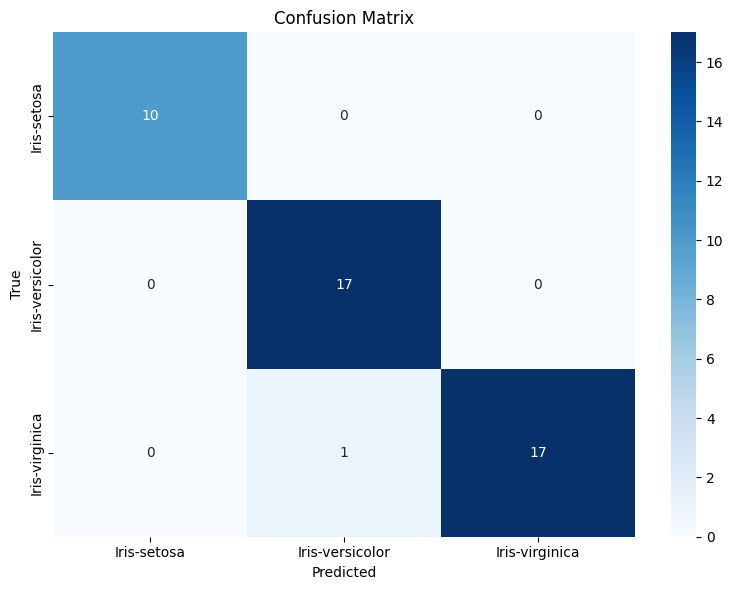

└── [petalwidth = <= 1.7]
    ├── [petallength = <= 4.9]
    │   ├── → Iris-versicolor
    ├── [petallength = > 4.9]
    │   └── → Iris-virginica
└── [petalwidth = <= 0.9]
    ├── → Iris-setosa
└── [petalwidth = > 1.7]
    └── [petallength = > 4.9]
        ├── → Iris-virginica
    └── [petallength = <= 4.9]
        └── → Iris-virginica


In [24]:
trainIris(split=0.7, kfold=True)

## Connect4 decision tree training
The trainconnect4() function trains a custom ID3 decision tree on MCTS-generated Connect Four data (mcts_moves.csv), and evaluates its performance.

What It Does
- Loads a dataset of (state → move) pairs generated by MCTS

- Splits the data into training and testing sets

- Trains an ID3 decision tree with configurable parameters:

    - max_depth: limits the tree size

    - min_samples_split: avoids overfitting on tiny subsets

    - min_gain: minimum information gain to split

- Optionally saves the model to connect4.pkl

Evaluation
- Computes and prints:

    - Training accuracy

    - Test accuracy

- Displays:

    - Confusion matrix of predictions

    - Multiclass ROC curve using predicted probabilities

In [ ]:
def train_popout(max_deph=15, min_split=1, min_gain=1e-2, split=0.7, save=False):
    df = pd.read_csv('mcts_moves.csv')

    X_train, X_test, y_train, y_test = train_test_split(df, split=split, target="move")

    tree = DecisionTreeID3(
        max_depth=max_deph,
        min_samples_split=min_split,
        min_gain=min_gain
    )

    tree.fit(X_train, y_train)

    if save:
        save_tree(tree, "popout.pkl")

    pred = tree.predict(X_test)

    y_pred_train = tree.predict(X_train)
    acc_train = accuracy(y_pred_train, y_train)
    print(f"Train accuracy: {acc_train:.2f}")

    pred_prob = tree.predict_probability(X_test)

    print(f"Test accuracy: {accuracy(pred, y_test)}")

    confusion_matrix(y_test, pred)
    plot_roc(y_test, pred_prob)

### Test hyper parameters

In [ ]:
train_popout(max_deph=6,min_split=100,min_gain=1e-2)

Train accuracy: 0.36
Test accuracy: 0.34583185106130676


KeyboardInterrupt: 

In [ ]:
train_popout(max_deph=10,min_split=100,min_gain=1e-2)

In [ ]:
train_popout(max_deph=15,min_split=100,min_gain=1e-2)

In [ ]:
train_popout(max_deph=10,min_split=4,min_gain=1e-4)

In [ ]:
train_popout(max_deph=10,min_split=10,min_gain=1e-2)

In [ ]:
train_popout(max_deph=10,min_split=1,min_gain=1e-2)

Train accuracy: 0.63
Test accuracy: 0.4648167911775169


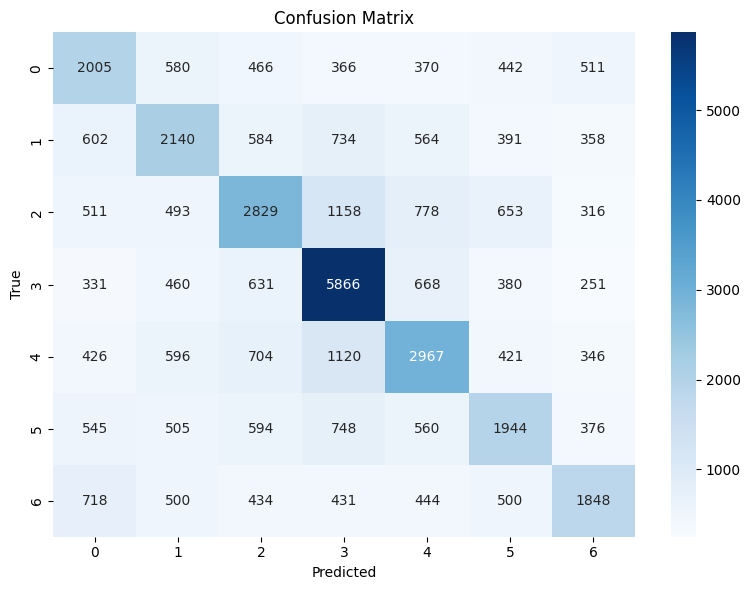

C:\Users\dinis\AppData\Local\Temp\ipykernel_10216\714529894.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y_sorted, x_sorted)


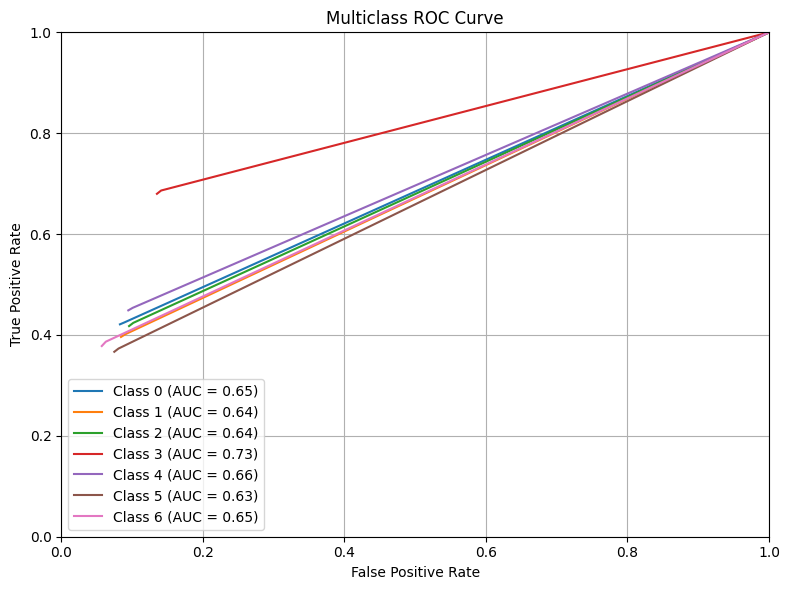

In [ ]:
train_popout(max_deph=10,min_split=1,min_gain=1e-20)

Train accuracy: 0.86
Test accuracy: 0.5120579544371366


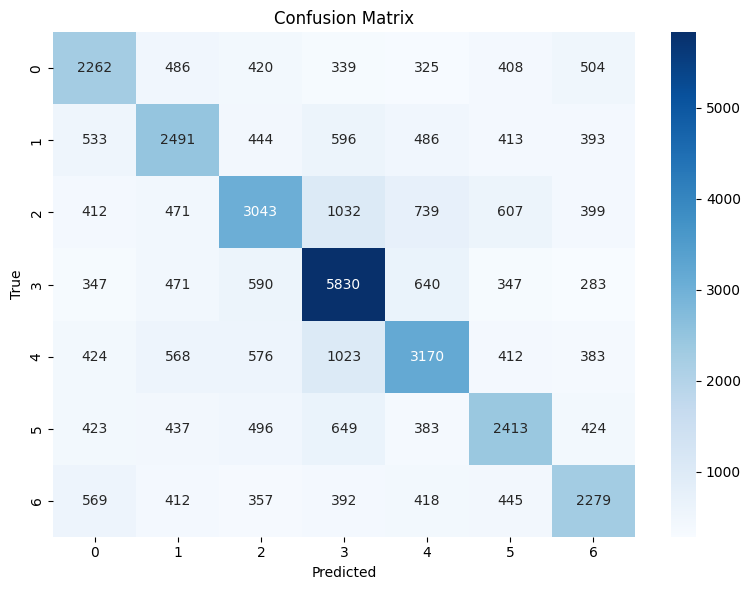

C:\Users\dinis\AppData\Local\Temp\ipykernel_16956\714529894.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y_sorted, x_sorted)


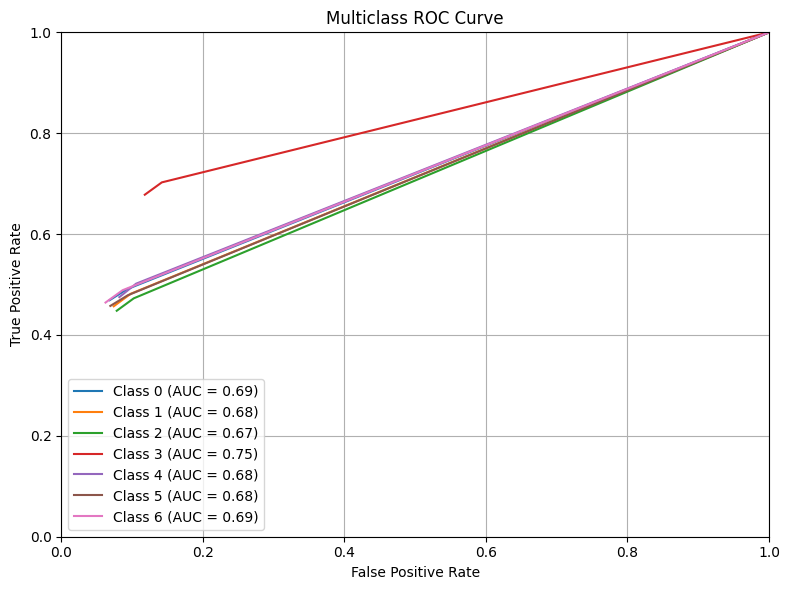

In [ ]:
train_popout(max_deph=15,min_split=1,min_gain=1e-2)

Train accuracy: 0.71
Test accuracy: 0.483223715565723


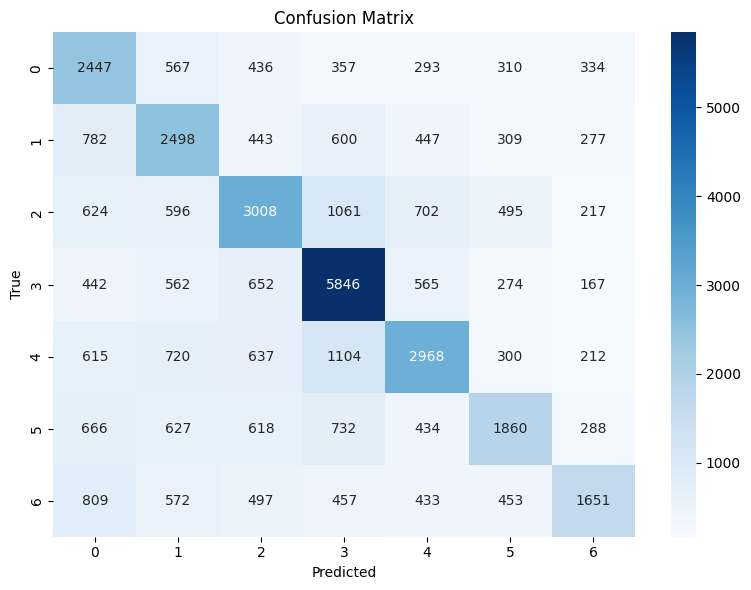

C:\Users\dinis\AppData\Local\Temp\ipykernel_16956\714529894.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y_sorted, x_sorted)


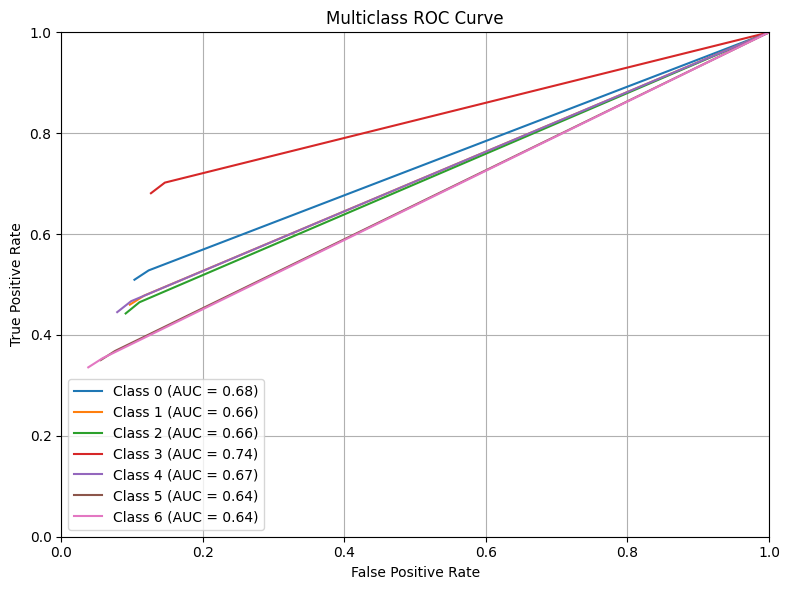

In [ ]:
train_popout(max_deph=15,min_split=2,min_gain=1e-4)

In [ ]:
train_popout(max_deph=18,min_split=1,min_gain=1e-2)

In [ ]:
train_popout(max_deph=20,min_split=4,min_gain=1e-2)

KeyboardInterrupt: 

### Save best model

Train accuracy: 0.87
Test accuracy: 0.5136307311028501


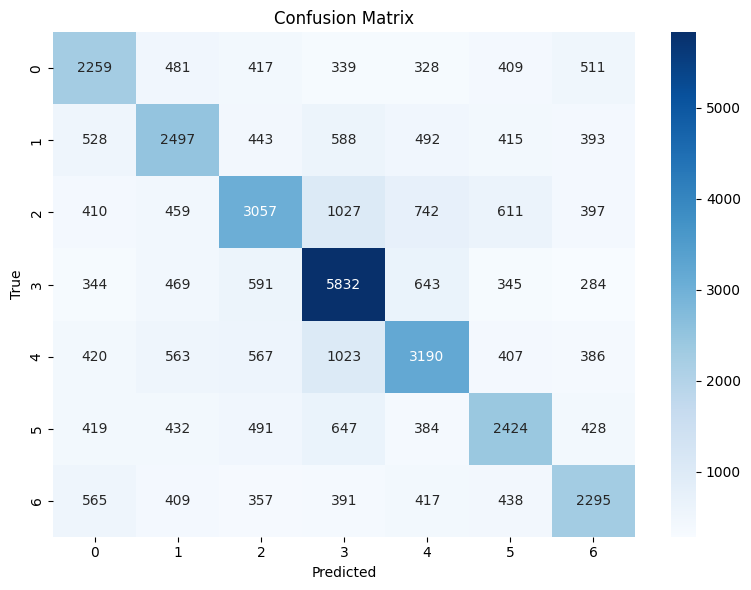

C:\Users\dinis\AppData\Local\Temp\ipykernel_16956\714529894.py:33: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(y_sorted, x_sorted)


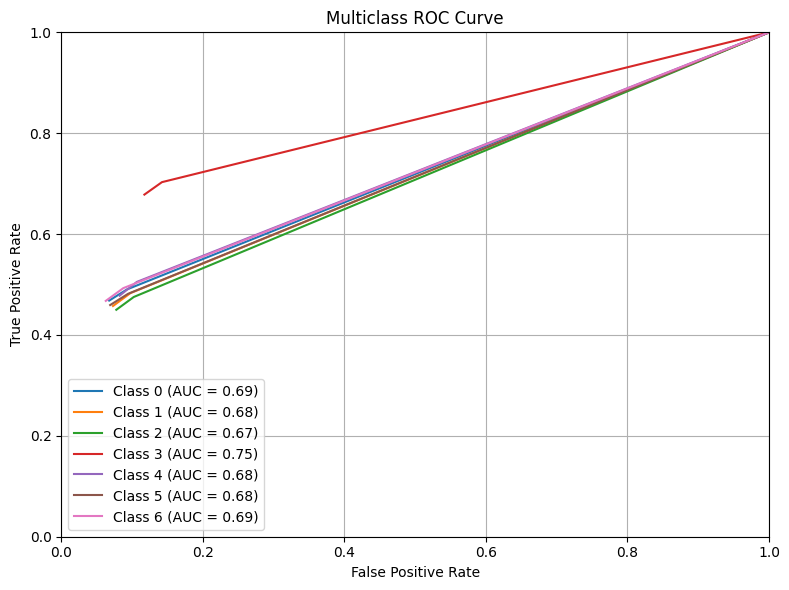

In [ ]:
train_popout(max_deph=20, save=True)

## Get id3 move
This section defines the ID3-based agent that selects moves using a pre-trained decision tree model.

How It Works:
- Loads a serialized decision tree (connect4.pkl) trained on (state → move) pairs.
- Converts the current board into a flat feature dictionary (s0 to s41) using board_to_state().
- Uses the tree's .predict() method to select the most likely move.
- If the predicted move is invalid (e.g., a full column), it defaults to a random valid move, with a warning.


In [ ]:
def ID3(**kwargs):
    board = kwargs.get("board")
    player = kwargs.get("player")

    with open('popout.pkl', "rb") as f:
        tree = pickle.load(f)

    state = board_to_state(board)
    move_label = tree.predict(pd.DataFrame([state]))[0]
    move = decode_move(move_label)

    valid_moves = get_valid_moves(board, player)

    if move not in valid_moves:
        print("[ID3] Jogada inválida para o estado atual. Vou escolher aleatoriamente.")
        move = random.choice(valid_moves)

    return move

In [ ]:
play_game(mode='pvc' , ai=ID3)

In [ ]:
benchmark_menu_jupyter()

In [ ]:
benchmark_menu_jupyter()